In [1]:
# This allows us to import from all folders one level up from notebooks folder - run 1 time
import sys
from pathlib import Path

print('All paths pre-append')
for i,p in enumerate(sys.path):
    print(f"{i}: {p}")
print('-'*100)

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
print('All paths post-append')
for i,p in enumerate(sys.path):
    print(f"{i}: {p}")


All paths pre-append
0: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python311.zip
1: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11
2: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/lib-dynload
3: 
4: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/site-packages
----------------------------------------------------------------------------------------------------
All paths post-append
0: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python311.zip
1: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11
2: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/lib-dynload
3: 
4: /Users/irabandutta/Developer/2026-08-llm-from-scratch/venv/lib/python3.11/site-packages
5: /Users/irabandutta/Developer/2026-08-llm-from-scratch


# Imports

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from src.model.llm_config import LLMConfig
from src.model.llm import LLM
from src.training.trainer import LLMTrainerConfig, LLMTrainer, TokenBatchLoader

# Defining a LLMTrainer object with default configs

In [3]:
# ======== SET Global Configs ========
B = 16
T = 128
STEPS = 25000
DEVICE = 'auto'

# ======== SET SEED ========
seed=42
torch.manual_seed(seed)


# ======== DEFINE Model Config ========
llm_config = LLMConfig(
    vocab_size=50304,     # Divisible by 128
    ctx_len=T,
    d_model=512, 
    n_layer=8,
    ff_ratio=4,
    dropout=0.0,
    eps=1e-5,
    bias=False,
    position_embedding='sinusoidal',
    rotary_embedding=False,
    attention='gqa',
    normalization='layernorm',
    n_heads=8, 
    n_groups=4,
    use_flash=True, 
    attn_debug=False
)
print(llm_config)
print('-'*50)


# ======== DEFINE Trainer Config ========
trainer_config = LLMTrainerConfig(
    num_steps=STEPS,
    batch_size=B,
    learning_rate=6e-4,
    weight_decay=0.01,
    beta1=0.9,
    beta2=0.95,
    use_lr_scheduler=True,
    warmup_steps=15,
    min_lr=0.1*6e-4,
    grad_clip=1.0,
    log_interval=10,
    eval_interval=100,
    eval_steps=16,
    to_save_checkpoint=True,
    checkpoint_interval=1000,
    device=DEVICE
)
print(trainer_config)
print('-'*50)

# ======== Instantiate Train Batch Loaders ========
print(f'Create generator for loading train data of shape ({B}, {T})')
binary_file_path = '../data/tinystories/processed/train.bin'
tok_bl = TokenBatchLoader(
    B=trainer_config.batch_size, 
    T=llm_config.ctx_len, 
    binary_file_path=binary_file_path, 
    dtype=np.uint16, 
    debug=False
)

# ======== Instantiate Val Batch Loaders ========
print(f'Create generator for loading validation data of shape ({B}, {T})')
binary_file_path = '../data/tinystories/processed/val.bin'
val_token_len = len(np.memmap(filename=binary_file_path, dtype=np.uint16, mode='r'))
tok_bl_val = TokenBatchLoader(
    B=trainer_config.batch_size, 
    T=llm_config.ctx_len, 
    binary_file_path=binary_file_path, 
    dtype=np.uint16, 
    debug=False
)

# ======== Instantiate model ========
model = LLM(config=llm_config)

# ======== Instantiate trainer ========
trainer = LLMTrainer(
    config=trainer_config,
    model=model,
    train_loader=tok_bl,
    val_loader=tok_bl_val
)

LLMConfig(vocab_size=50304, ctx_len=128, d_model=512, n_layer=8, ff_ratio=4, dropout=0.0, eps=1e-05, bias=False, position_embedding='sinusoidal', rotary_embedding=False, attention='gqa', normalization='layernorm', n_heads=8, n_groups=4, use_flash=True, attn_debug=False)
--------------------------------------------------
LLMTrainerConfig(num_steps=25000, batch_size=16, learning_rate=0.0006, weight_decay=0.01, beta1=0.9, beta2=0.95, use_lr_scheduler=True, warmup_steps=15, min_lr=5.9999999999999995e-05, grad_clip=1.0, log_interval=10, eval_interval=100, eval_steps=16, to_save_checkpoint=True, checkpoint_interval=1000, checkpoint_dir='./checkpoints/2026_08_23_10_55_02', device='auto')
--------------------------------------------------
Create generator for loading train data of shape (16, 128)
Loaded 471.872517M tokens
1 epoch ~ 230406 steps
--------------------------------------------------
Create generator for loading validation data of shape (16, 128)
Loaded 4.743928M tokens
1 epoch ~ 23

# Load Checkpoint

In [4]:
best_ckpt_path1 = '/Users/irabandutta/Developer/2026-08-llm-from-scratch/checkpoints/2026_08_23_03_48_39/bestt.pt'
best_ckpt_path2 = '/Users/irabandutta/Developer/2026-08-llm-from-scratch/checkpoints/2026_08_23_03_48_39/best.pt'
latest_ckpt_path = '/Users/irabandutta/Developer/2026-08-llm-from-scratch/checkpoints/2026_08_23_03_48_39/latest.pt'

try:
    best_ckpt = trainer.load_checkpoint(best_ckpt_path1)
except Exception as e:
    print(e)

best_ckpt = trainer.load_checkpoint(best_ckpt_path2, weights_only=False)
latest_ckpt = trainer.load_checkpoint(latest_ckpt_path, weights_only=False)

File not found at path /Users/irabandutta/Developer/2026-08-llm-from-scratch/checkpoints/2026_08_23_03_48_39/bestt.pt


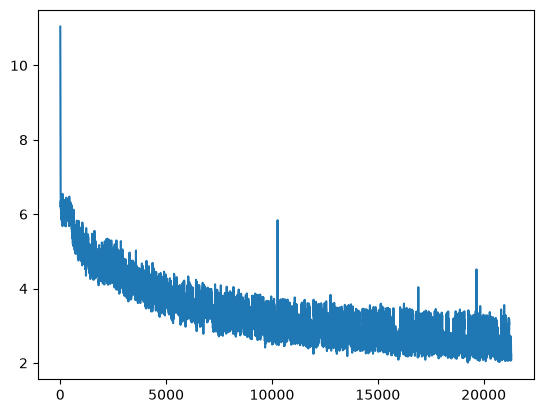

In [5]:
loss_hist = best_ckpt['train_loss_hist']
plt.plot(loss_hist)
plt.show()

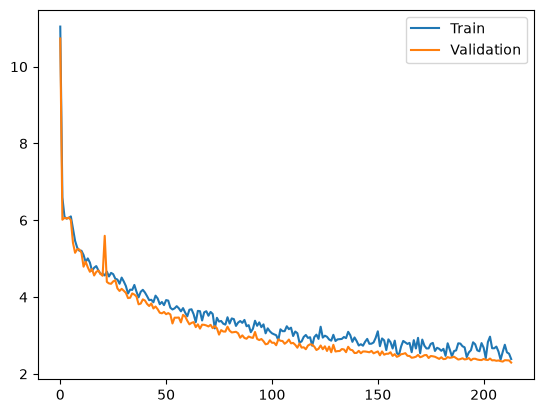

In [6]:
loss_hist_smooth = np.array(loss_hist[1:]).reshape(-1, 100).mean(axis=-1)
loss_hist_smooth = np.concatenate([[loss_hist[0]], loss_hist_smooth], axis=0)
val_loss_hist = best_ckpt['val_loss_hist']
plt.plot(loss_hist_smooth, label="Train")
plt.plot(val_loss_hist, label="Validation")
plt.legend()
plt.show()

# Resume Training

In [7]:
print(best_ckpt.keys())
print(latest_ckpt.keys())

dict_keys(['model_state_dict', 'optimizer_state_dict', 'model_config', 'train_config', 'step', 'train_loss_hist', 'val_loss_hist', 'train_loader_state', 'rng_state'])
dict_keys(['model_state_dict', 'optimizer_state_dict', 'model_config', 'train_config', 'step', 'train_loss_hist', 'val_loss_hist', 'train_loader_state', 'rng_state'])


In [8]:
print('Difference b/w states of newly initialized LLMTrainer object vs older object (saved as ckpt)')

# Model_config
print(trainer.model.config)
print(best_ckpt['model_config'])
print(latest_ckpt['model_config'])
print('-'*50)

# Trainer_config
print(trainer.config)
print(best_ckpt['train_config'])
print(latest_ckpt['train_config'])
print('-'*50)

# Trainer step
print(trainer.step)
print(best_ckpt['step'])
print(latest_ckpt['step'])
print('-'*50)

# Train Loader curr_idx (to resume)
print(trainer.train_loader.curr_idx)
print(best_ckpt['train_loader_state']['curr_idx'])
print(latest_ckpt['train_loader_state']['curr_idx'])
print('-'*50)

# Train Loss Hist
print(trainer.train_loss_hist, len(trainer.train_loss_hist))
print(len(best_ckpt['train_loss_hist']))
print(len(latest_ckpt['train_loss_hist']))
print('-'*50)

# Val Loss Hist
print(trainer.val_loss_hist, len(trainer.val_loss_hist))
print(len(best_ckpt['val_loss_hist']))
print(len(latest_ckpt['val_loss_hist']))

Difference b/w states of newly initialized LLMTrainer object vs older object (saved as ckpt)
LLMConfig(vocab_size=50304, ctx_len=128, d_model=512, n_layer=8, ff_ratio=4, dropout=0.0, eps=1e-05, bias=False, position_embedding='sinusoidal', rotary_embedding=False, attention='gqa', normalization='layernorm', n_heads=8, n_groups=4, use_flash=True, attn_debug=False)
LLMConfig(vocab_size=50304, ctx_len=128, d_model=512, n_layer=8, ff_ratio=4, dropout=0.0, eps=1e-05, bias=False, position_embedding='sinusoidal', rotary_embedding=False, attention='gqa', normalization='layernorm', n_heads=8, n_groups=4, use_flash=True, attn_debug=False)
LLMConfig(vocab_size=50304, ctx_len=128, d_model=512, n_layer=8, ff_ratio=4, dropout=0.0, eps=1e-05, bias=False, position_embedding='sinusoidal', rotary_embedding=False, attention='gqa', normalization='layernorm', n_heads=8, n_groups=4, use_flash=True, attn_debug=False)
--------------------------------------------------
LLMTrainerConfig(num_steps=25000, batch_siz